In [2]:
import re
import random
import time
from collections import Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 10

# To reset seeds later for reproduceability
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
# Use gpu instead of cpu if possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# load Ag News dataset
dataset = load_dataset("sh0416/ag_news")

df_train_full = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

#Create train test and dev datasets
df_train, df_dev = train_test_split(
    df_train_full, test_size=0.1, random_state=SEED,
    stratify=df_train_full["label"],
)
df_train = df_train.reset_index(drop=True)
df_dev = df_dev.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Subsample for speed
df_train = df_train.sample(n=5000, random_state=SEED).reset_index(drop=True)
df_dev = df_dev.sample(n=1000,  random_state=SEED).reset_index(drop=True)
df_test = df_test.sample(n=1000, random_state=SEED).reset_index(drop=True)

# Put title and description together
for df in [df_train, df_dev, df_test]:
    df["text"] = df["title"] + " " + df["description"]

# Dataset categories
AG_LABELS = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
NUM_CLASSES = 4


c:\Users\erik\OneDrive\EStuff\University\yr2\nlp\assingment 2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Regex to group by words with letters & numbers together, remove punctuation
TOKEN_RE = re.compile(r"[A-Za-z0-9']+")

def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())

# Tokens for Pads & Unknown
PAD, UNK = "<pad>", "<unk>"

# Get rid of rarely used words
def build_vocab(texts, min_freq: int = 2, max_size: int = 30000) -> dict:
    """
    Build a vocabulary mapping from tokens to integer indices.
    The vocabulary will include only tokens that appear at least `min_freq` times,
    and will be limited to `max_size` tokens (including PAD and UNK).
    """
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    # Reserve 0 for PAD and 1 for UNK.
    vocab = {PAD: 0, UNK: 1}
    for word, freq in counter.most_common():
        if freq < min_freq or len(vocab) >= max_size:
            break
        vocab[word] = len(vocab)
    return vocab

def numericalize(tokens: list, vocab: dict) -> None:
    return [vocab.get(t, vocab[UNK]) for t in tokens]

vocab = build_vocab(df_train["text"])
VOCAB_SZ = len(vocab)
PAD_IDX = vocab[PAD]

In [4]:
MAX_LEN = 128
BATCH_SIZE = 64

@dataclass
class Batch:
    x: torch.Tensor # (B, T) token ids
    lengths: torch.Tensor # (B,) true lengths
    y: torch.Tensor  # (B,) labels

# Dataset wrapper for vocab
class TextDataset(Dataset):
    def __init__(self, df, vocab: dict, max_len: int=MAX_LEN):
        self.df, self.vocab, self.max_len = df, vocab, max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        # Convert row -> token -> number
        ids = numericalize(tokenize(str(row["text"])), self.vocab)[: self.max_len]
        return ids or [self.vocab[UNK]], int(row["label"]) - 1

# 
def collate(batch: list) -> Batch:
    """Collate function to convert a list of samples into a batch."""
    # batch: list of (ids_list, label)
    # lengths needed for LSTM
    lengths = torch.tensor([len(x) for x, _ in batch], dtype=torch.long)
    # padd with <pad>
    x = torch.full((len(batch), int(lengths.max())), PAD_IDX, dtype=torch.long)
    y = torch.tensor([lbl for _, lbl in batch], dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        x[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)
    return Batch(x=x, lengths=lengths, y=y)

# Batch, shuffle + load
train_loader = DataLoader(TextDataset(df_train, vocab), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate)
dev_loader = DataLoader(TextDataset(df_dev,   vocab), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader = DataLoader(TextDataset(df_test,  vocab), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)



In [5]:

EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_FILTERS = 128
KERNEL_SIZES = (3, 4, 5)
DROPOUT = 0.3

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int =EMBED_DIM, hidden_dim: int=HIDDEN_DIM,
                 num_layers: int =2, dropout: float=DROPOUT, pad_idx: int =PAD_IDX, num_classes: int =NUM_CLASSES):
        super().__init__()
        # Convert word indexes -> vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        # Prevent overfitting by removing some words to rely on other words as well
        self.emb_drop = nn.Dropout(dropout)
        # LSTM Recurrent network
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.rep_drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        emb = self.emb_drop(self.embedding(x))  # (B, T, E)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed) # h_n: (num_layers * dirs, B, H)
        return self.fc(self.rep_drop(h_n[-1]))  # last layer, last direction


class CNNTextClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int=EMBED_DIM, num_filters: int=NUM_FILTERS,
                 kernel_sizes: tuple=KERNEL_SIZES, dropout: float=DROPOUT, pad_idx: int=PAD_IDX, num_classes: int=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)  # (B, T, E)
        self.emb_drop = nn.Dropout(dropout)
        self.convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes])
        self.rep_drop = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x, lengths):
        # x: (B, T)
        emb = self.emb_drop(self.embedding(x)).transpose(1, 2) # (B, E, T)
        # Concatenate features of strongest activation in sentence
        pooled = [torch.relu(conv(emb)).max(dim=2).values for conv in self.convs]
        return self.fc(self.rep_drop(torch.cat(pooled, dim=1)))



In [6]:
LR = 0.001 # Training weight updates
MAX_EPOCHS = 20
PATIENCE = 5 # to stop early

def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    all_y, all_pred = [], []
    total_loss, n = 0, 0
    # Not computing gradients as no training anymore
    with torch.no_grad():
        for batch in loader:
            # Batching data for processing
            x, lengths, y = batch.x.to(device), batch.lengths.to(device), batch.y.to(device)
            # Probabilities for each class & Calculate loss
            logits = model(x, lengths)
            total_loss += loss_fn(logits, y).item() * y.size(0)
            # Store the real label
            all_y.append(y.cpu().numpy())
            # Store the most likely label
            all_pred.append(logits.argmax(1).cpu().numpy())
            n += y.size(0)
    # All real vs predicted labels
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    return {
        "loss": total_loss / max(n, 1),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true, "y_pred": y_pred,
    }


def fit(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, lr=LR, max_epochs=MAX_EPOCHS,
        patience=PATIENCE)  -> list:
    """
    Train the model, optionally with early stopping on validation loss.

    If clip_grad_norm is not None, gradients are clipped by global norm after backward.
    We log the pre clipping total gradient norm each epoch.
    """
    # Same loss classification
    loss_fn   = nn.CrossEntropyLoss()
    # Optimizes learning rates
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    # Reduce step size when hitting learning curve plateau
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

    best_val, best_state, bad_epochs = float("inf"), None, 0
    # Statistics training history / epoch
    history = []


    for epoch in range(1, max_epochs + 1):
        model.train()
        # measure epoch duration
        t0 = time.perf_counter()
        total_loss, n, correct = 0, 0, 0
        for batch in train_loader:
            x, lengths, y = batch.x.to(device), batch.lengths.to(device), batch.y.to(device)
            # Clear old grads
            optimizer.zero_grad(set_to_none=True)
            # Get predicions
            logits = model(x, lengths)

            # Prediction error + calc gradients
            loss = loss_fn(logits, y)
            loss.backward()
            # Limit the models gradient
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update params, batch loss and processed samples
            optimizer.step()
            total_loss += loss.item() * y.size(0)
            n += y.size(0)
            # Count correct predictions
            correct += (logits.argmax(1) == y).sum().item()

        # Test
        val = evaluate(model, val_loader)
        # Based on loss change learning rate
        scheduler.step(val["loss"])
        history.append(dict(epoch=epoch,
                            train_loss=total_loss / max(n, 1), train_acc=correct / max(n, 1),
                            val_loss=val["loss"], val_acc=val["acc"], val_f1=val["f1"],
                            time_s=time.perf_counter() - t0))
        r = history[-1]
        print(f"[{epoch:02d}]train_loss={r['train_loss']:.4f} acc={r['train_acc']:.4f} | "
                f"val_loss={r['val_loss']:.4f} acc={r['val_acc']:.4f} f1={r['val_f1']:.4f} | "
                f"{r['time_s']:.1f}s")

        # Check for enough improvement in each epoch
        if val["loss"] < best_val - 1e-6:
            best_val, bad_epochs = val["loss"], 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return history

In [ ]:
# Reset seeds again to ensure independent reproducability
set_seed()
lstm_model = LSTMClassifier(VOCAB_SZ).to(device)
set_seed()
cnn_model  = CNNTextClassifier(VOCAB_SZ).to(device)

print("Training LSTM...")
hist_lstm = fit(lstm_model, train_loader, dev_loader)
val_lstm, test_lstm = evaluate(lstm_model, dev_loader), evaluate(lstm_model, test_loader)

print("\nTraining CNN...")
hist_cnn  = fit(cnn_model, train_loader, dev_loader)
val_cnn, test_cnn = evaluate(cnn_model, dev_loader), evaluate(cnn_model, test_loader)


print("\nResults")
for name, val, test in [("LSTM", val_lstm, test_lstm), ("CNN", val_cnn, test_cnn)]:
    print(f"{name}: val_acc={val['acc']:.4f} val_f1={val['f1']:.4f} | "
          f"test_acc={test['acc']:.4f} test_f1={test['f1']:.4f}")

label_names = [AG_LABELS[i] for i in range(NUM_CLASSES)]
reportLSTM = classification_report(test_lstm["y_true"], test_lstm["y_pred"], target_names=label_names)
reportCNN = classification_report(test_cnn["y_true"],  test_cnn["y_pred"],  target_names=label_names)

print("LSTM:\n", reportLSTM)
print("CNN:\n", reportCNN)



Training LSTM...
[01]train_loss=1.3240 acc=0.3578 | val_loss=1.1179 acc=0.5030 f1=0.4309 | 22.0s
[02]train_loss=1.0363 acc=0.5466 | val_loss=0.8760 acc=0.6440 f1=0.6375 | 23.4s
[03]train_loss=0.7948 acc=0.6840 | val_loss=0.6934 acc=0.7440 f1=0.7401 | 38.1s
[04]train_loss=0.6407 acc=0.7566 | val_loss=0.6327 acc=0.7600 f1=0.7557 | 26.6s
[05]train_loss=0.5157 acc=0.8100 | val_loss=0.5714 acc=0.7930 f1=0.7915 | 21.9s
[06]train_loss=0.4400 acc=0.8464 | val_loss=0.5492 acc=0.7990 f1=0.7976 | 21.0s
[07]train_loss=0.3755 acc=0.8736 | val_loss=0.6129 acc=0.7990 f1=0.7978 | 37.0s
[08]train_loss=0.3303 acc=0.8816 | val_loss=0.6341 acc=0.7980 f1=0.7946 | 24.9s
[09]train_loss=0.2858 acc=0.9042 | val_loss=0.5370 acc=0.8330 f1=0.8318 | 21.5s
[10]train_loss=0.2602 acc=0.9098 | val_loss=0.5687 acc=0.8270 f1=0.8257 | 49.5s
[11]train_loss=0.2219 acc=0.9282 | val_loss=0.6283 acc=0.8220 f1=0.8189 | 37.9s
[12]train_loss=0.1971 acc=0.9338 | val_loss=0.6685 acc=0.8240 f1=0.8223 | 27.9s
[13]train_loss=0.1548 a

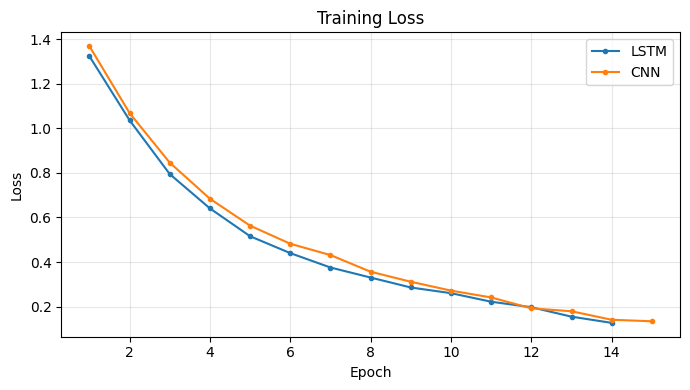

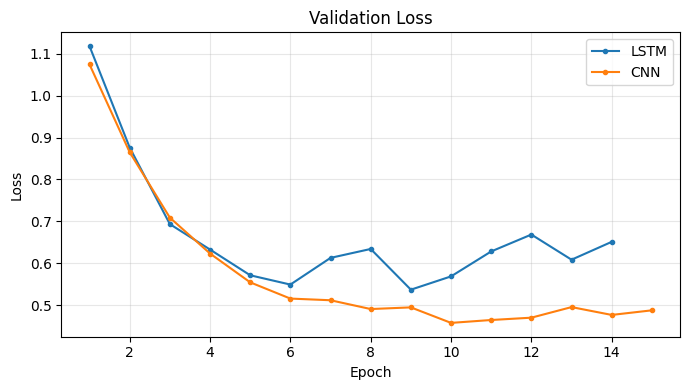

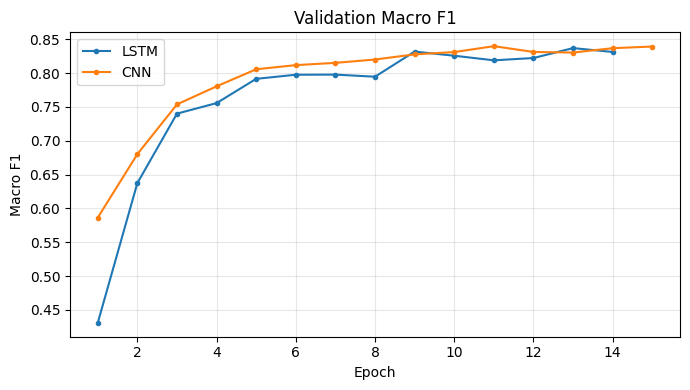

In [8]:
# Helper function to plot curves over epochs
def plot_curves(histories, names, metric, ylabel, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    for hist, name in zip(histories, names):
        ax.plot([h["epoch"] for h in hist], [h[metric] for h in hist],
                marker="o", markersize=3, label=name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

plot_curves([hist_lstm, hist_cnn], ["LSTM", "CNN"], "train_loss", "Loss", "Training Loss")
plot_curves([hist_lstm, hist_cnn], ["LSTM", "CNN"], "val_loss", "Loss", "Validation Loss")
plot_curves([hist_lstm, hist_cnn], ["LSTM", "CNN"], "val_f1", "Macro F1", "Validation Macro F1")

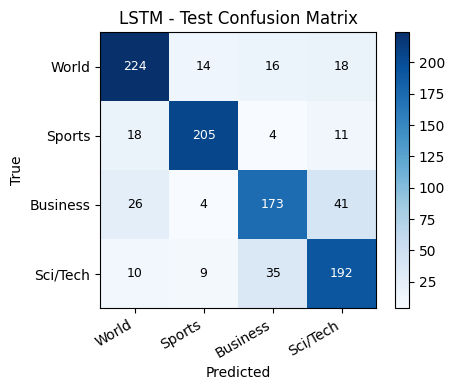

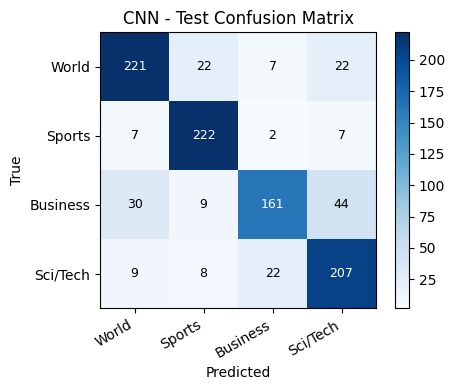

In [9]:
# Plot confusion matrixies
def plot_cm(y_true, y_pred, title):
    # Compute matrix
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    # Set matrix classes
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(label_names, rotation=30, ha="right")
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels(label_names)
    thresh = cm.max() / 2
    # Print values for each square
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > thresh else "black")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

plot_cm(test_lstm["y_true"], test_lstm["y_pred"], "LSTM - Test Confusion Matrix")
plot_cm(test_cnn["y_true"],  test_cnn["y_pred"],  "CNN - Test Confusion Matrix")



In [10]:
def get_misclassified_examples(model, df, max_items=10):
    model.eval()
    errs = []
    # For each text & label
    for _, row in df.iterrows():
        # Regular tokenize -> Token ids like before
        tokens = tokenize(str(row["text"]))
        ids = numericalize(tokens, vocab)[:MAX_LEN] or [vocab[UNK]]
        x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
        lengths = torch.tensor([len(ids)], dtype=torch.long).to(device)
        y = int(row["label"]) - 1
        # See what the model has predicted
        with torch.no_grad():
            pred = int(model(x, lengths).argmax(dim=1).item())
        # If its wrong
        if pred != y:
            snippet = row["text"].replace("\n", " ")
            snippet = snippet[:250] + ("..." if len(snippet) > 250 else "")
            errs.append((y, pred, snippet))
        if len(errs) >= max_items:
            break
    return errs

def show_errors(name, errs):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    for i, (y, p, snip) in enumerate(errs):
        print(f"\nerror {i+1}")
        print(f"  true: {AG_LABELS[y]}  pred: {AG_LABELS[p]}")
        print(f"  text: {snip}")

errs_lstm = get_misclassified_examples(lstm_model, df_test, max_items=10)
errs_cnn  = get_misclassified_examples(cnn_model,  df_test, max_items=10)

show_errors("LSTM errors", errs_lstm)
show_errors("CNN errors",  errs_cnn)



LSTM errors

error 1
  true: World  pred: Sci/Tech
  text: Int #39;l conference calls for mine-free world Senior officials of 143 governments are calling for the total ban of production and use of anti-personnel landmine. Senior government officials of 143 countries across the world 

error 2
  true: Business  pred: Sci/Tech
  text: FaceTime, IMlogic Back Live Communications Server 2005 Hard on the heels of Microsoft announcing that it #39;s taken Live Communications Server 2005 gold, instant messaging management software vendors IMlogic and FaceTime on Tuesday both touted their...

error 3
  true: Business  pred: Sci/Tech
  text: Telephone Tag (Forbes.com) Forbes.com - ARRIS GROUP (5, ARRS) saw its market cap unjustifiably halved recently when Comcast, a huge customer (24 of Arris' sales), hinted it might buy next-generation technology from Cisco Systems. Arris supplies the t...

error 4
  true: Business  pred: Sci/Tech
  text: Oracle v. Peoplesoft: the joke is on... Opinion I though

Ablation: Dropout
[01]train_loss=1.2604 acc=0.3984 | val_loss=1.0013 acc=0.5580 f1=0.5327 | 28.5s
[02]train_loss=0.8231 acc=0.6746 | val_loss=0.7596 acc=0.7180 f1=0.7140 | 42.7s
[03]train_loss=0.5492 acc=0.7974 | val_loss=0.6410 acc=0.7570 f1=0.7546 | 42.2s
[04]train_loss=0.3667 acc=0.8702 | val_loss=0.6435 acc=0.7640 f1=0.7637 | 40.9s
[05]train_loss=0.2663 acc=0.9138 | val_loss=0.6735 acc=0.7790 f1=0.7757 | 41.7s
[06]train_loss=0.2091 acc=0.9362 | val_loss=0.7278 acc=0.7700 f1=0.7680 | 43.6s
[07]train_loss=0.1306 acc=0.9618 | val_loss=0.7200 acc=0.7860 f1=0.7843 | 46.1s
[08]train_loss=0.0921 acc=0.9740 | val_loss=0.7107 acc=0.7920 f1=0.7898 | 43.0s
Early stopping at epoch 8
LSTM dropout=0.0: val_f1=0.7546 test_f1=0.7437
[01]train_loss=1.3178 acc=0.3544 | val_loss=1.1334 acc=0.4790 f1=0.4186 | 43.7s
[02]train_loss=1.0073 acc=0.5724 | val_loss=0.8474 acc=0.6700 f1=0.6612 | 43.3s
[03]train_loss=0.7688 acc=0.7024 | val_loss=0.6996 acc=0.7470 f1=0.7447 | 42.9s
[04]train_loss=0.6161 acc=0.7

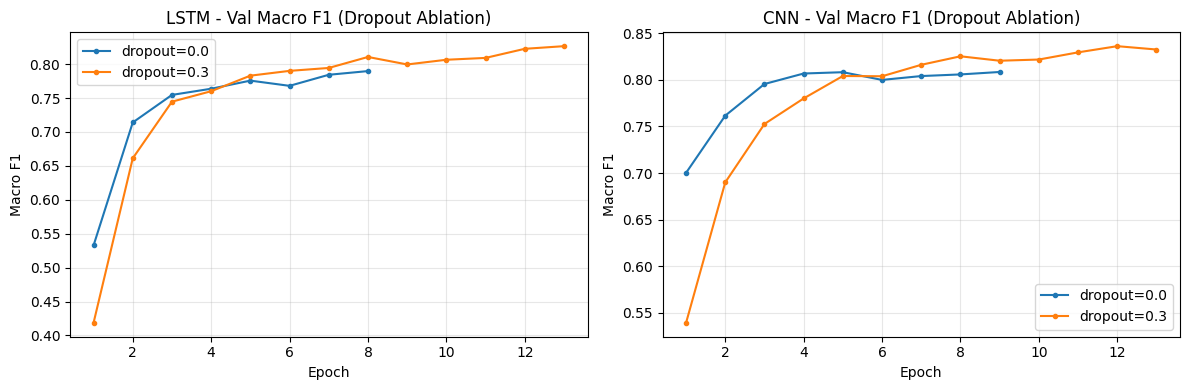

In [11]:
print("Ablation: Dropout")

ablation_results = []
# For each architecture / model
for arch, ModelClass in [("LSTM", LSTMClassifier), ("CNN", CNNTextClassifier)]:
    for dropout in (0.0, 0.3):
        set_seed()
        # Load & train new model
        model = ModelClass(VOCAB_SZ, dropout=dropout).to(device)
        hist = fit(model, train_loader, dev_loader)
        # Test loss like before
        val = evaluate(model, dev_loader)
        test = evaluate(model, test_loader)
        print(f"{arch} dropout={dropout}: val_f1={val['f1']:.4f} test_f1={test['f1']:.4f}")
        ablation_results.append((arch, dropout, hist, val, test))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Plot for both architectures at the same time
for ax, arch_name in zip(axes, ["LSTM", "CNN"]):
    # For each experiment
    for arch, dropout, hist, _, _ in ablation_results:
        if arch == arch_name:
            ax.plot([h["epoch"] for h in hist], [h["val_f1"] for h in hist],
                    marker="o", markersize=3, label=f"dropout={dropout}")
    ax.set_title(f"{arch_name} - Val Macro F1 (Dropout Ablation)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro F1")
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
